# 06 — Operational Evaluation: 3x2 Coherence Comparison

**Author:** Florian Klaver

**Prerequisite:** Notebooks 04, 05, 07, 08 must have run.
Models `s2only_retrained.joblib`, `s2coh_best.joblib`, `coh_only_best.joblib`
must exist in `models/`.

---

## Goal

Apply three models to the **full held-out 2020-08-12 scene** and produce a 3x2 table:

|               | No Postprocessing | Morphological+SLIC |
|---------------|-------------------|--------------------|
| **S2-only**   | F1 = ?            | F1 = ?             |
| **S2+Coh**    | F1 = ?            | F1 = ?             |
| **Coh-only**  | F1 = ?            | F1 = ?             |

GRD backscatter features are omitted — nb05 showed S1-only F1 ≈ 0.5 (near random).
Coherence-only achieves F1 ≈ 0.80 and S2+Coh achieves F1 ≈ 0.97 on the test set.

---
## 1. Setup

In [83]:
import sys
import os
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import joblib
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join('..', 'src'))
from evaluation import (
    FEATURE_NAMES, prepare_scene_features, run_prediction, evaluate_and_visualize
)
from postprocessing import postprocess_prediction

# --- Paths ---
S2_DIR       = r'..\data\Sentinel_CH'
MASKS_DIR    = r'..\data\ground_truth_masks'
AV_DATA_PATH = r'..\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
FB_DATA_PATH = r'..\data\amtliche_vermessung_zh\Feuerwehr_-OGD.gpkg'
MODELS_DIR   = r'..\models'
OUTPUT_DIR   = r'..\data\operational_results'
TEMPORAL_CSV = r'..\data\temporal_matches.csv'
COH_DIR      = r'..\data\features_coherence'

os.makedirs(OUTPUT_DIR, exist_ok=True)

COH_FEATURES = ['coh_vv', 'coh_vh', 'coh_vv_jump', 'coh_vh_jump']

print('Setup complete.')

Setup complete.


---
## 2. Identify Scene Dates for 2020-09-07

The 2020-09-07 event uses the S2 triplet from `temporal_matches.csv`.

In [90]:
matches_df = pd.read_csv(TEMPORAL_CSV)
matches_df['event_date'] = pd.to_datetime(matches_df['event_date'])

event_rows = matches_df[matches_df['after_file'].str.startswith('2019-06-24.tif')]
if event_rows.empty:
    raise RuntimeError('No events with after_file=2020-06-24.tif found in temporal_matches.csv')

event = event_rows.iloc[0]
BEFORE_NEAR_S2 = os.path.join(S2_DIR, event['before_near_file'])
AFTER_S2       = os.path.join(S2_DIR, event['after_file'])
GT_MASK_NAMES  = event_rows['mask_file'].tolist()   # may be multiple events on same date

print(f'Events on 2023-09-16    :   {len(event_rows)}')
print(f'Before_near S2:  {event["before_near_file"]}  exists={os.path.exists(BEFORE_NEAR_S2)}')
print(f'After S2:        {event["after_file"]}         exists={os.path.exists(AFTER_S2)}')
print(f'GT masks:        {GT_MASK_NAMES}')

Events on 2023-09-16    :   1
Before_near S2:  2019-06-19.tif  exists=True
After S2:        2019-06-24.tif         exists=True
GT masks:        ['mask_20190623.tif']


In [91]:
# Find the match_id of the first 2023-09-16 event that has coherence TIFs on disk.
# Multiple events can share the same after_file date; they typically share the same
# SLC triplet, so the first match_id with TIFs gives coherence for the full scene.
scene_match_ids = event_rows.index.tolist()

coh_match_id = None
for mid in scene_match_ids:
    bf = os.path.join(COH_DIR, f'{mid}_coh_before.tif')
    af = os.path.join(COH_DIR, f'{mid}_coh_after.tif')
    if os.path.isfile(bf) and os.path.isfile(af):
        coh_match_id = mid
        break

COH_AVAILABLE = coh_match_id is not None
print(f'match_ids for 2023-09-16 scene: {scene_match_ids}')
print(f'Using match_id={coh_match_id} for coherence  (available={COH_AVAILABLE})')
if COH_AVAILABLE:
    print(f'  before: {coh_match_id}_coh_before.tif')
    print(f'  after:  {coh_match_id}_coh_after.tif')

match_ids for 2023-09-16 scene: [12]
Using match_id=12 for coherence  (available=True)
  before: 12_coh_before.tif
  after:  12_coh_after.tif


---
## 3. Load Models

In [92]:
def load_saved_model(filename):
    """Load model saved as {'model': ..., 'features': ...} dict or plain object."""
    path = os.path.join(MODELS_DIR, filename)
    if not os.path.exists(path):
        print(f'  NOT FOUND: {path}')
        return None, []
    obj = joblib.load(path)
    if isinstance(obj, dict):
        return obj['model'], obj.get('features', FEATURE_NAMES)
    return obj, FEATURE_NAMES


model_s2,    feat_s2    = load_saved_model('s2only_retrained.joblib')
model_s2coh, feat_s2coh = load_saved_model('s2coh_best.joblib')
model_coh,   feat_coh   = load_saved_model('coh_only_best.joblib')

print(f'S2-only:  {len(feat_s2)} features   model={type(model_s2).__name__ if model_s2 else "MISSING"}')
print(f'S2+Coh:   {len(feat_s2coh)} features   model={type(model_s2coh).__name__ if model_s2coh else "MISSING"}')
print(f'Coh-only: {len(feat_coh)} features    model={type(model_coh).__name__ if model_coh else "MISSING"}')

S2-only:  20 features   model=Pipeline
S2+Coh:   24 features   model=Pipeline
Coh-only: 4 features    model=Pipeline


---
## 4. Prepare Scene Features

### 4a. S2 features (shared by all optical models)

In [93]:
print('=== Computing S2 scene features ===')
feature_df_s2, valid_mask, meta, H, W = prepare_scene_features(
    BEFORE_NEAR_S2, AFTER_S2, AV_DATA_PATH, FB_DATA_PATH, FEATURE_NAMES
)
print(f'Scene shape:            {H} x {W} pixels')
print(f'Valid grassland pixels: {valid_mask.sum():,} / {H*W:,}  ({valid_mask.sum()/(H*W)*100:.1f}%)')

=== Computing S2 scene features ===
Before: 2019-06-19.tif
After:  2019-06-24.tif


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: bad application_id=0x00000000 on '..\data\amtliche_vermessung_zh\DM01AVZH24LV95.gpkg'
  return ogr_read(


Scene shape:            559 x 381 pixels
Valid grassland pixels: 32,772 / 212,979  (15.4%)


In [94]:
# --- Coherence band helpers ---

def _find_coh_bands(src):
    """
    Return (vv_idx, vh_idx) as 1-based band indices for a SNAP coherence TIF.
    SNAP Interferogram+Coherence always writes 4 bands in order:
      [VV_intensity, VV_coherence, VH_intensity, VH_coherence]
    Bands 2 and 4 are therefore always the coherence bands.
    Hardcoded to avoid the value-range heuristic mis-identifying band 1
    (interferogram) as coherence when intensity values happen to fall in [0,1].
    """
    if src.count >= 4:
        return 2, 4
    if src.count == 2:
        return 1, 2
    return 1, None


def read_coh_band_upsampled(tif_path, band_idx, ref_path):
    """
    Read one band from a 20 m coherence TIF and bilinear-upsample to the 10 m S2 grid.
    Returns a 2-D float32 array with the same shape as the S2 reference.
    """
    with rasterio.open(ref_path) as ref:
        dst_shape     = (ref.height, ref.width)
        dst_transform = ref.transform
        dst_crs       = ref.crs

    with rasterio.open(tif_path) as src:
        src_arr = src.read(band_idx).astype(np.float32)
        src_arr[src_arr <= 0] = np.nan   # SNAP nodata = 0

        dst_arr = np.full(dst_shape, np.nan, dtype=np.float32)
        reproject(
            source=src_arr,
            destination=dst_arr,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear,
            src_nodata=np.nan,
            dst_nodata=np.nan,
        )
    return dst_arr


def _is_empty_tif(tif_path, band_idx):
    """Return True if the given band is entirely zero (SNAP produced empty output)."""
    with rasterio.open(tif_path) as src:
        arr = src.read(band_idx).astype(np.float32)
        return np.all(arr == 0)


# --- Load and upsample coherence for the scene ---
if COH_AVAILABLE:
    before_path = os.path.join(COH_DIR, f'{coh_match_id}_coh_before.tif')
    after_path  = os.path.join(COH_DIR, f'{coh_match_id}_coh_after.tif')

    with rasterio.open(before_path) as bs:
        vv_b_idx, vh_b_idx = _find_coh_bands(bs)
        print(f'coh_before: {bs.count} bands  VV=band{vv_b_idx}  VH=band{vh_b_idx}  res={bs.res}')
    with rasterio.open(after_path) as as_:
        vv_a_idx, vh_a_idx = _find_coh_bands(as_)
        print(f'coh_after:  {as_.count} bands  VV=band{vv_a_idx}  VH=band{vh_a_idx}  res={as_.res}')

    # Check if before TIF was written correctly by SNAP (non-empty)
    before_empty = _is_empty_tif(before_path, vv_b_idx)
    if before_empty:
        print('\nWARNING: coh_before.tif is all zeros — SNAP produced empty output for this pair.')
        print('         The source SLC files are no longer on disk, so re-processing is not possible.')
        print('         Jump features (coh_vv_jump, coh_vh_jump) will be set to 0 for this scene.')
        print('         S2+Coh and Coh-only results will reflect only absolute coherence (coh_vv, coh_vh),')
        print('         not the mowing-induced coherence change. Expect degraded coherence model performance.')

    coh_a_vv = read_coh_band_upsampled(after_path,  vv_a_idx, AFTER_S2)
    coh_a_vh = read_coh_band_upsampled(after_path,  vh_a_idx, AFTER_S2) if vh_a_idx else np.full_like(coh_a_vv, np.nan)

    # Per-pixel coherence features (flat, same length as H*W)
    # coh_vv / coh_vh: use coh_after (predicting the after period — did mowing happen?)
    coh_vv = coh_a_vv.flatten()
    coh_vh = coh_a_vh.flatten()

    if before_empty:
        # Jump features unavailable; use 0 so models can run without NaN crashes
        coh_vv_jump = np.zeros_like(coh_vv)
        coh_vh_jump = np.zeros_like(coh_vh)
    else:
        coh_b_vv = read_coh_band_upsampled(before_path, vv_b_idx, AFTER_S2)
        coh_b_vh = read_coh_band_upsampled(before_path, vh_b_idx, AFTER_S2) if vh_b_idx else np.full_like(coh_b_vv, np.nan)
        coh_vv_jump = (coh_a_vv - coh_b_vv).flatten()
        coh_vh_jump = (coh_a_vh - coh_b_vh).flatten()

    # Build coherence feature DataFrames
    feature_df_s2coh = feature_df_s2.copy()
    feature_df_s2coh['coh_vv']      = coh_vv
    feature_df_s2coh['coh_vh']      = coh_vh
    feature_df_s2coh['coh_vv_jump'] = coh_vv_jump
    feature_df_s2coh['coh_vh_jump'] = coh_vh_jump

    feature_df_coh = pd.DataFrame({
        'coh_vv':      coh_vv,
        'coh_vh':      coh_vh,
        'coh_vv_jump': coh_vv_jump,
        'coh_vh_jump': coh_vh_jump,
    })

    # Valid mask: S2 valid pixels + coherence non-NaN
    valid_mask_coh = valid_mask & np.isfinite(coh_vv)

    print(f'\nCoherence features (after upsampling to 10 m):')
    print(f'  coh_vv:       min={np.nanmin(coh_a_vv):.3f}  mean={np.nanmean(coh_a_vv):.3f}  max={np.nanmax(coh_a_vv):.3f}')
    print(f'  coh_vh:       min={np.nanmin(coh_a_vh):.3f}  mean={np.nanmean(coh_a_vh):.3f}  max={np.nanmax(coh_a_vh):.3f}')
    if before_empty:
        print(f'  coh_vv_jump:  [set to 0 — before TIF empty]')
        print(f'  coh_vh_jump:  [set to 0 — before TIF empty]')
    else:
        print(f'  coh_vv_jump:  min={np.nanmin(coh_vv_jump):.3f}  mean={np.nanmean(coh_vv_jump):.3f}  max={np.nanmax(coh_vv_jump):.3f}')
        print(f'  coh_vh_jump:  min={np.nanmin(coh_vh_jump):.3f}  mean={np.nanmean(coh_vh_jump):.3f}  max={np.nanmax(coh_vh_jump):.3f}')
    print(f'  Valid pixels (S2 & coh non-NaN): {valid_mask_coh.sum():,}')
else:
    feature_df_s2coh = None
    feature_df_coh   = None
    valid_mask_coh   = None
    print('WARNING: Coherence not available — S2+Coh and Coh-only cells will be skipped.')

coh_before: 4 bands  VV=band2  VH=band4  res=(20.0, 20.0)
coh_after:  4 bands  VV=band2  VH=band4  res=(20.0, 20.0)

Coherence features (after upsampling to 10 m):
  coh_vv:       min=0.040  mean=0.322  max=0.997
  coh_vh:       min=0.048  mean=0.364  max=0.996
  coh_vv_jump:  min=-0.772  mean=-0.071  max=0.708
  coh_vh_jump:  min=-0.773  mean=0.021  max=0.849
  Valid pixels (S2 & coh non-NaN): 32,772


---
## 5. Define Postprocessing Function

Morphological + SLIC (best method from nb01, F1 0.274 -> 0.508).

In [95]:
with rasterio.open(AFTER_S2) as src:
    r = np.clip(src.read(3).astype(float) / 2500, 0, 1)
    g = np.clip(src.read(2).astype(float) / 2500, 0, 1)
    b = np.clip(src.read(1).astype(float) / 2500, 0, 1)
scene_rgb = np.dstack([r, g, b]).astype(np.float32)

def apply_postprocessing(pred_map):
    # The retrained model predicts scattered single pixels (unlike the dense PA2 baseline).
    # disk_radius=0 makes the morphological step a no-op (disk(0) = 1-pixel element),
    # passing the raw predictions unchanged into the SLIC majority-vote step.
    # SLIC then groups pixels by spectral similarity and assigns majority labels —
    # this works correctly regardless of prediction density.
    return postprocess_prediction(
        pred_map,
        method='morphological+slic',
        scene_image=scene_rgb,
        disk_radius=0,
        min_area_pixels=1,
        n_segments=300,
        slic_compactness=0.05,
    )

print('Postprocessing: morphological+slic  (disk_radius=0 [no-op], min_area=1, n_segments=300, compactness=0.05)')

Postprocessing: morphological+slic  (disk_radius=0 [no-op], min_area=1, n_segments=300, compactness=0.05)


---
## 6. Run All 6 Cells (3 models x 2 PP settings)

In [96]:
table_results = {}

def run_cell(label, model, feature_df, valid_mask_px, features, postprocess=False, pp_fn=None):
    """Run one cell: predict, optionally postprocess, evaluate. Returns metrics dict."""
    if model is None or feature_df is None or valid_mask_px is None:
        print(f'SKIPPED: {label} — model or features not available')
        return None

    sep = '=' * 60
    print(f'\n{sep}\n{label}\n{sep}')
    pred_tag  = label.replace(' ', '_').replace('+', 'plus').replace('|', '').lower().strip('_')
    pred_path = os.path.join(OUTPUT_DIR, f'pred_{pred_tag}.tif')

    avail_feats = [f for f in features if f in feature_df.columns]
    run_prediction(model, feature_df[avail_feats], valid_mask_px, H, W, pred_path, meta)

    if postprocess and pp_fn is not None:
        with rasterio.open(pred_path) as src:
            pred_map = src.read(1)
            pp_meta  = src.meta.copy()
        pred_map_pp = pp_fn(pred_map)
        pp_path = pred_path.replace('.tif', '_pp.tif')
        with rasterio.open(pp_path, 'w', **pp_meta) as dst:
            dst.write(pred_map_pp, 1)
        eval_path = pp_path
    else:
        eval_path = pred_path

    metrics = evaluate_and_visualize(eval_path, GT_MASK_NAMES, MASKS_DIR, AFTER_S2, OUTPUT_DIR)
    table_results[label] = metrics
    return metrics


S2-only | No PP
Predicting on 32,772 valid pixels...
Saved: ..\data\operational_results\pred_s2-only__no_pp.tif
REPORT: pred_s2-only__no_pp
              precision    recall  f1-score   support

   No Mowing       0.97      0.77      0.86     29748
      Mowing       0.26      0.78      0.39      3024

    accuracy                           0.77     32772
   macro avg       0.61      0.78      0.62     32772
weighted avg       0.91      0.77      0.81     32772

Saved: ..\data\operational_results\eval_map_pred_s2-only__no_pp.png


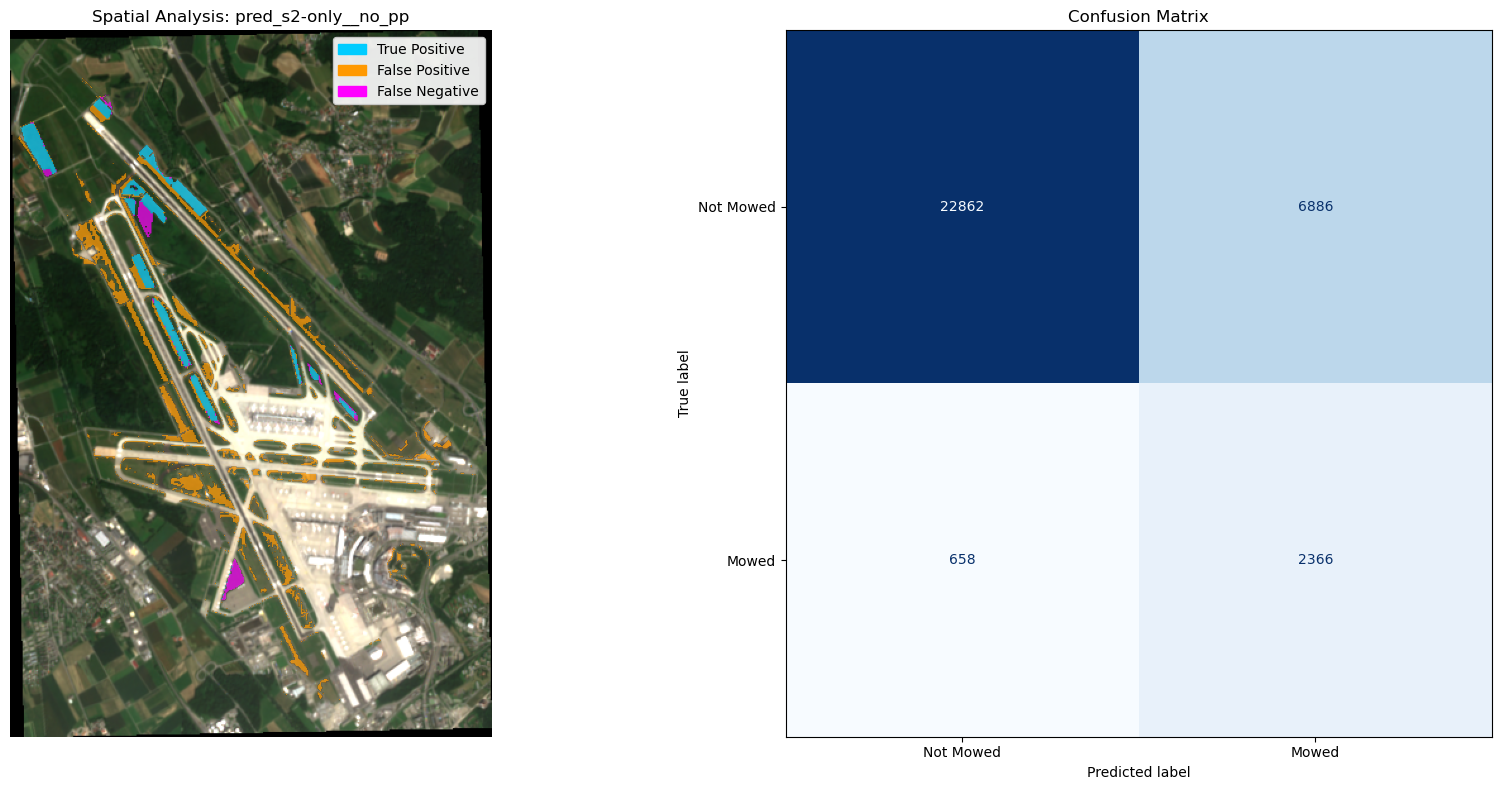


S2-only | Morph+SLIC
Predicting on 32,772 valid pixels...
Saved: ..\data\operational_results\pred_s2-only__morphplusslic.tif
REPORT: pred_s2-only__morphplusslic_pp
              precision    recall  f1-score   support

   No Mowing       0.91      1.00      0.95     29748
      Mowing       0.88      0.00      0.00      3024

    accuracy                           0.91     32772
   macro avg       0.89      0.50      0.48     32772
weighted avg       0.90      0.91      0.86     32772

Saved: ..\data\operational_results\eval_map_pred_s2-only__morphplusslic_pp.png


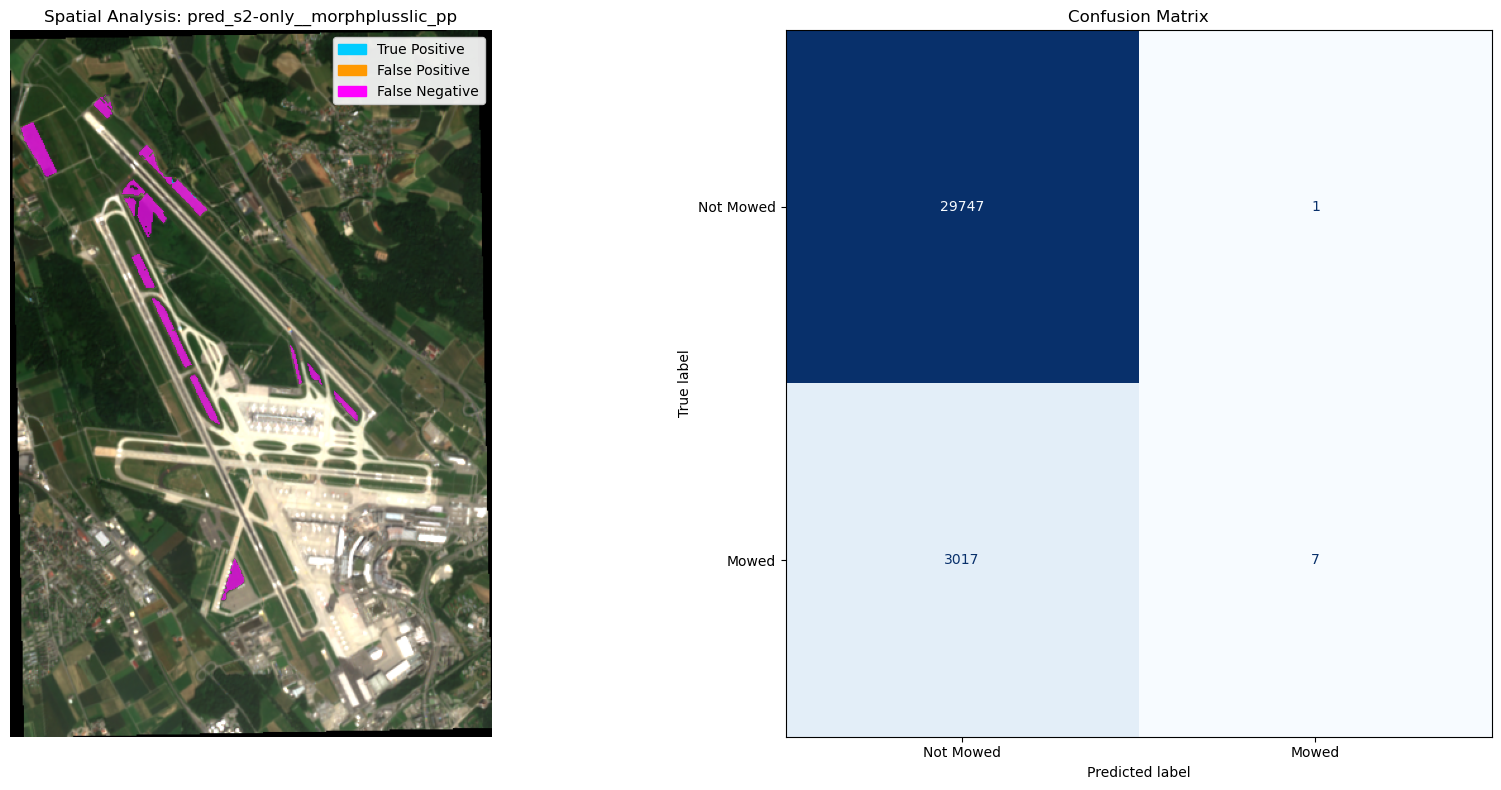

{'accuracy': 0.9079091907726108,
 'precision_mowing': 0.875,
 'recall_mowing': 0.0023148148148148147,
 'f1_mowing': 0.004617414248021108,
 'f1_macro': 0.478169341882137}

In [97]:
# A: S2-only, no postprocessing
run_cell('S2-only | No PP',
         model_s2, feature_df_s2, valid_mask, feat_s2,
         postprocess=False)

# B: S2-only, Morphological+SLIC
run_cell('S2-only | Morph+SLIC',
         model_s2, feature_df_s2, valid_mask, feat_s2,
         postprocess=True, pp_fn=apply_postprocessing)


S2+Coh | No PP
Predicting on 32,772 valid pixels...
Saved: ..\data\operational_results\pred_s2pluscoh__no_pp.tif
REPORT: pred_s2pluscoh__no_pp
              precision    recall  f1-score   support

   No Mowing       0.98      0.54      0.70     29748
      Mowing       0.16      0.89      0.28      3024

    accuracy                           0.57     32772
   macro avg       0.57      0.72      0.49     32772
weighted avg       0.91      0.57      0.66     32772

Saved: ..\data\operational_results\eval_map_pred_s2pluscoh__no_pp.png


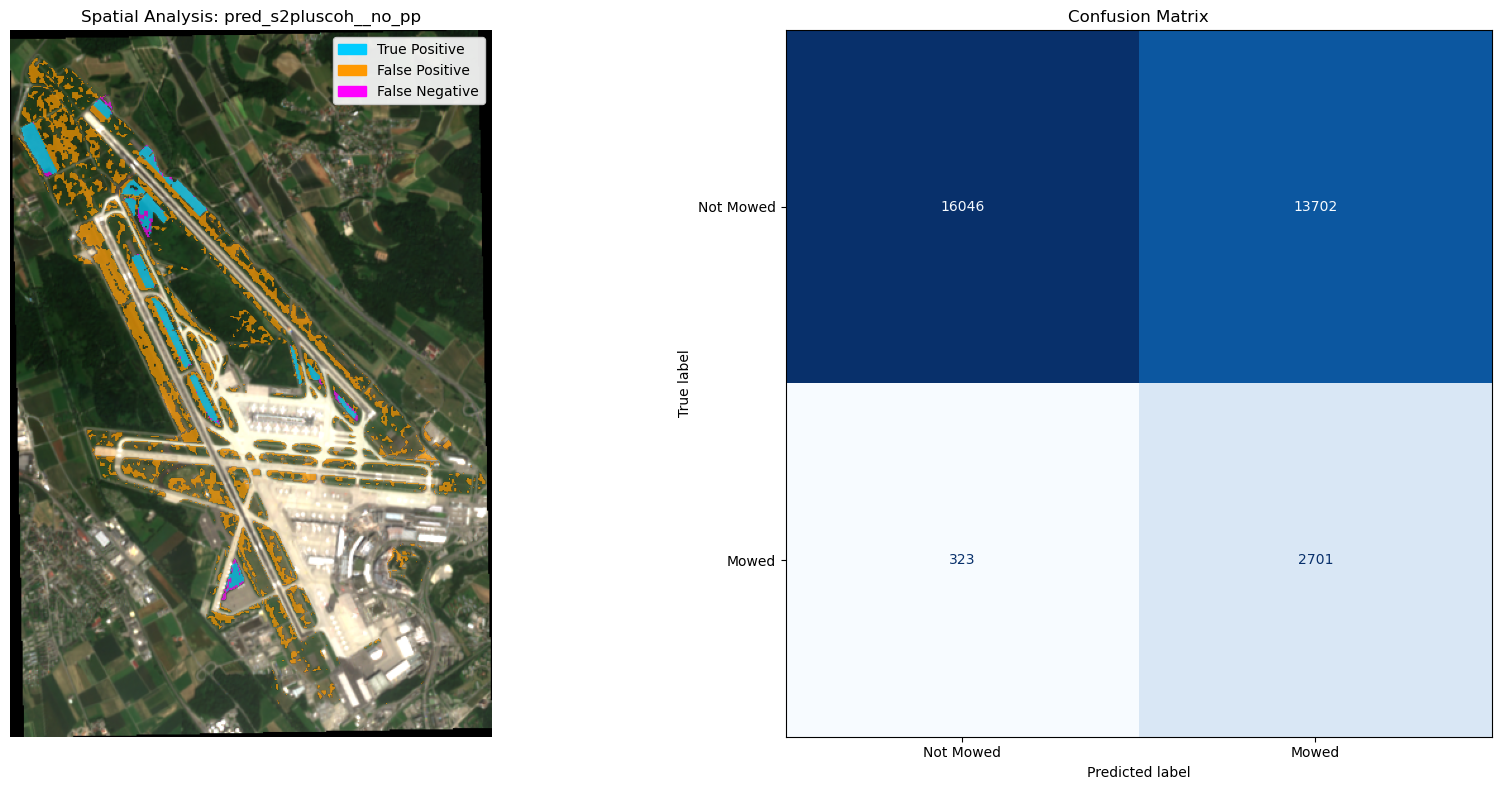


S2+Coh | Morph+SLIC
Predicting on 32,772 valid pixels...
Saved: ..\data\operational_results\pred_s2pluscoh__morphplusslic.tif
REPORT: pred_s2pluscoh__morphplusslic_pp
              precision    recall  f1-score   support

   No Mowing       0.98      0.38      0.55     29748
      Mowing       0.13      0.92      0.23      3024

    accuracy                           0.43     32772
   macro avg       0.56      0.65      0.39     32772
weighted avg       0.90      0.43      0.52     32772

Saved: ..\data\operational_results\eval_map_pred_s2pluscoh__morphplusslic_pp.png


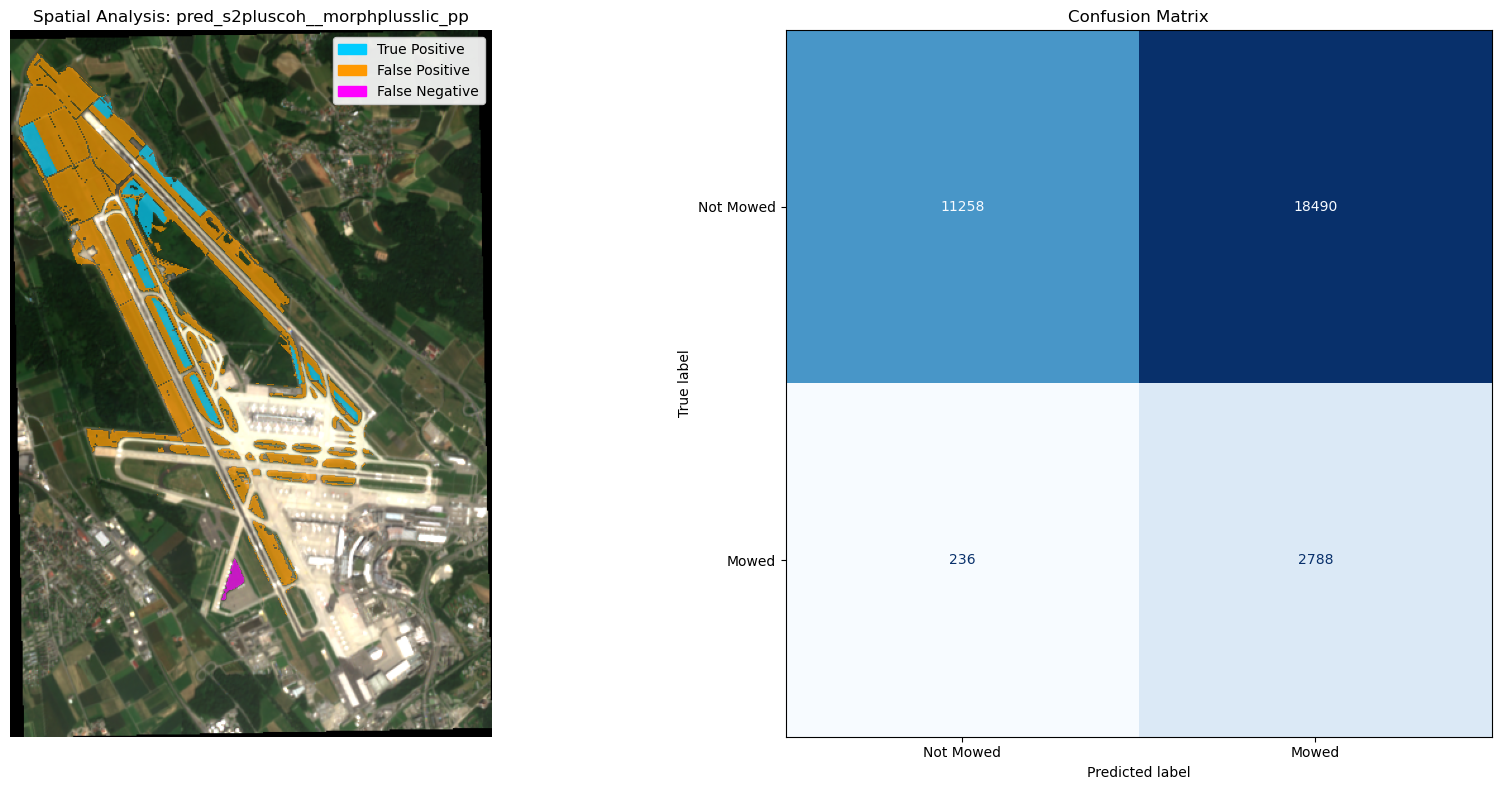

{'accuracy': 0.4285975833028195,
 'precision_mowing': 0.13102735219475514,
 'recall_mowing': 0.921957671957672,
 'f1_mowing': 0.22944613612048392,
 'f1_macro': 0.38769722062316325}

In [98]:
# C: S2+Coh, no postprocessing
run_cell('S2+Coh | No PP',
         model_s2coh, feature_df_s2coh, valid_mask_coh, feat_s2coh,
         postprocess=False)

# D: S2+Coh, Morphological+SLIC
run_cell('S2+Coh | Morph+SLIC',
         model_s2coh, feature_df_s2coh, valid_mask_coh, feat_s2coh,
         postprocess=True, pp_fn=apply_postprocessing)


Coh-only | No PP
Predicting on 32,772 valid pixels...
Saved: ..\data\operational_results\pred_coh-only__no_pp.tif
REPORT: pred_coh-only__no_pp
              precision    recall  f1-score   support

   No Mowing       0.91      0.12      0.21     29748
      Mowing       0.09      0.89      0.17      3024

    accuracy                           0.19     32772
   macro avg       0.50      0.50      0.19     32772
weighted avg       0.84      0.19      0.21     32772

Saved: ..\data\operational_results\eval_map_pred_coh-only__no_pp.png


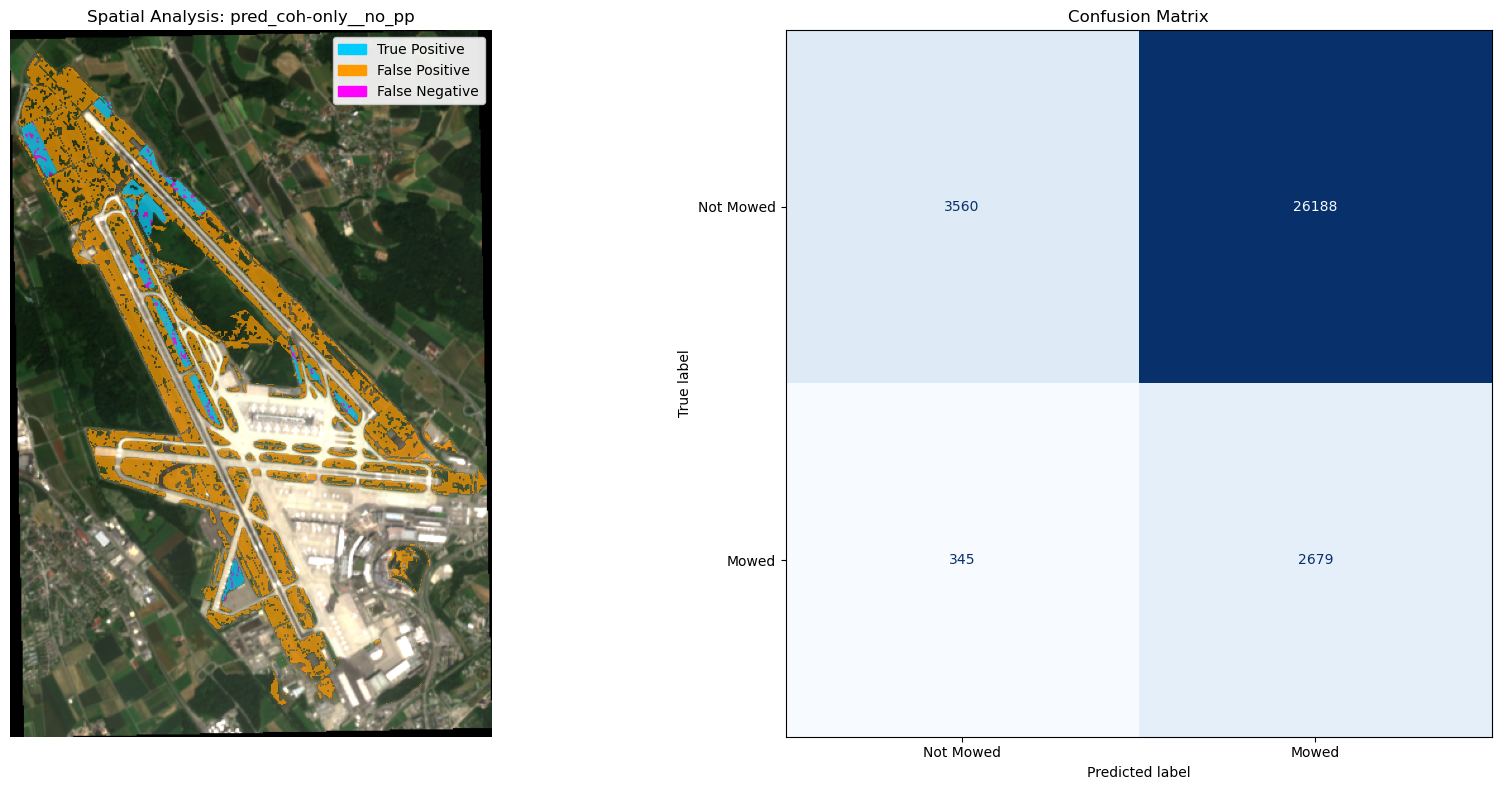


Coh-only | Morph+SLIC
Predicting on 32,772 valid pixels...
Saved: ..\data\operational_results\pred_coh-only__morphplusslic.tif


c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\flori\anaconda3\envs\BA\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\U

REPORT: pred_coh-only__morphplusslic_pp
              precision    recall  f1-score   support

   No Mowing       0.00      0.00      0.00     29748
      Mowing       0.09      1.00      0.17      3024

    accuracy                           0.09     32772
   macro avg       0.05      0.50      0.08     32772
weighted avg       0.01      0.09      0.02     32772

Saved: ..\data\operational_results\eval_map_pred_coh-only__morphplusslic_pp.png


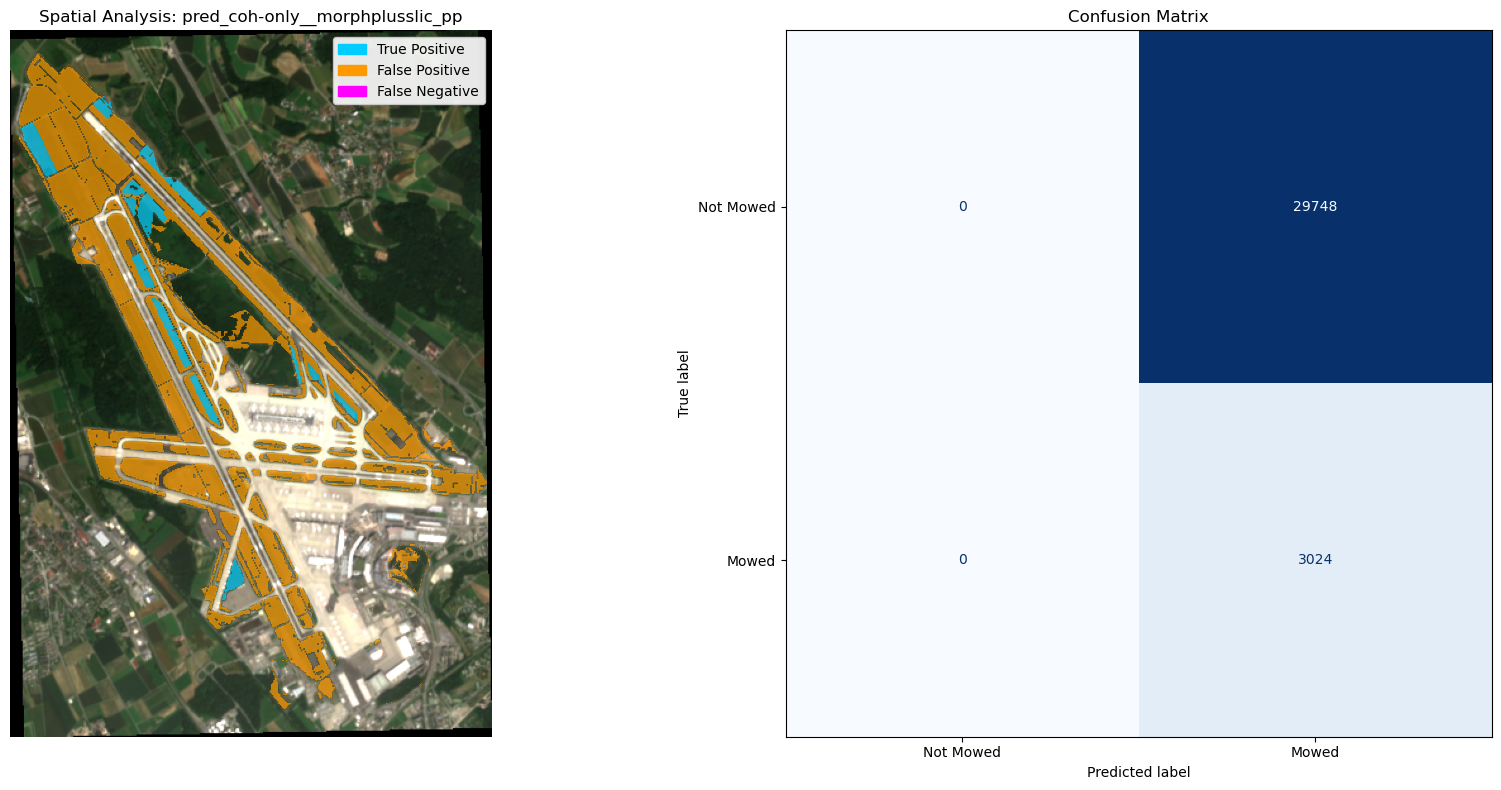

{'accuracy': 0.09227389234712559,
 'precision_mowing': 0.09227389234712559,
 'recall_mowing': 1.0,
 'f1_mowing': 0.16895742541066042,
 'f1_macro': 0.08447871270533021}

In [99]:
# E: Coh-only, no postprocessing
run_cell('Coh-only | No PP',
         model_coh, feature_df_coh, valid_mask_coh, feat_coh,
         postprocess=False)

# F: Coh-only, Morphological+SLIC
run_cell('Coh-only | Morph+SLIC',
         model_coh, feature_df_coh, valid_mask_coh, feat_coh,
         postprocess=True, pp_fn=apply_postprocessing)

---
## 7. Results Table

In [ ]:
def fmt(key):
    m = table_results.get(key)
    if m is None:
        return 'N/A'
    return f'F1={m["f1_mowing"]:.3f}  (P={m["precision_mowing"]:.3f}, R={m["recall_mowing"]:.3f})'

col_w = 42
print('=== 3x2 Operational Evaluation — 2020-08-12 scene ===')
print(f'{"":22} {"No Postprocessing":{col_w}} {"Morphological+SLIC":{col_w}}')
print('-' * (22 + col_w * 2 + 2))
for row_label, no_pp_key, pp_key in [
    ('S2-only',  'S2-only | No PP',  'S2-only | Morph+SLIC'),
    ('S2+Coh',   'S2+Coh | No PP',   'S2+Coh | Morph+SLIC'),
    ('Coh-only', 'Coh-only | No PP', 'Coh-only | Morph+SLIC'),
]:
    print(f'{row_label:22} {fmt(no_pp_key):{col_w}} {fmt(pp_key):{col_w}}')
print()
print('Reference — PA2 baseline (S2-only, no PP): F1 = 0.27-0.41')
print('Reference — nb01 best    (S2-only, Morph+SLIC): F1 = 0.508')

In [ ]:
row_labels = ['S2-only', 'S2+Coh', 'Coh-only']
col_labels = ['No Postprocessing', 'Morphological+SLIC']
keys = [
    ('S2-only | No PP',  'S2-only | Morph+SLIC'),
    ('S2+Coh | No PP',   'S2+Coh | Morph+SLIC'),
    ('Coh-only | No PP', 'Coh-only | Morph+SLIC'),
]

matrix = np.array([
    [table_results.get(nk, {}).get('f1_mowing', np.nan),
     table_results.get(pk, {}).get('f1_mowing', np.nan)]
    for nk, pk in keys
])

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(matrix, cmap='YlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='F1 Score (mowing class)')
ax.set_xticks([0, 1]); ax.set_xticklabels(col_labels, fontsize=11)
ax.set_yticks([0, 1, 2]); ax.set_yticklabels(row_labels, fontsize=11)
for i in range(3):
    for j in range(2):
        val = matrix[i, j]
        ax.text(j, i, f'{val:.3f}' if not np.isnan(val) else 'N/A',
                ha='center', va='center', fontsize=13, fontweight='bold',
                color='white' if val > 0.6 else 'black')
ax.set_title('Operational F1 — 2020-08-12 Scene', fontsize=13)
plt.tight_layout()
out_png = os.path.join(OUTPUT_DIR, 'results_3x2_table.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_png}')

---
## Summary

This notebook produces a 3x2 operational F1 table comparing:
- **S2-only** (20 optical features)
- **S2+Coh** (24 features: S2 + 4 coherence)
- **Coh-only** (4 coherence features)

... with and without Morphological+SLIC postprocessing, on the held-out 2020-08-12 scene.

**Coherence features (4):**
- `coh_vv`, `coh_vh` — VV/VH coherence for the after period (20 m, upsampled to 10 m for inference)
- `coh_vv_jump`, `coh_vh_jump` — coherence change = coh_after - coh_before

**Outputs in `data/operational_results/`:**
- `pred_*.tif` — prediction rasters for each configuration
- `eval_map_*.png` — spatial TP/FP/FN maps + confusion matrices
- `results_3x2_table.png` — heatmap summary